In [1]:
from unicodedata import category

import matplotlib.pyplot as plt
import pandas as pd

### 🍌 Categorías de Plátano

- **Super**: Categoría superior que agrupa los plátanos de mayor calidad, con características óptimas en tamaño, color y ausencia de defectos.

- **Gabaceras**: Marca premium de Europlátano, reconocida por su sabor y calidad, cultivada principalmente en el Valle de Aridane, La Palma.

- **Prim**: Categoría que incluye plátanos de primera calidad, con ligeras variaciones en tamaño o color respecto a la categoría "Super".

- **Seg**: Categoría segunda, que agrupa plátanos con defectos leves que no afectan su consumo.

- **Canary Gold**: Marca de plátanos de alta calidad, también comercializada por Europlátano, destacada por su sabor y textura.

- **Mnj**: Abreviatura que podría referirse a "Manojo", indicando un conjunto de plátanos agrupados para su venta.

- **Gab BIO**: Plátanos de la marca Gabaceras cultivados bajo prácticas de agricultura ecológica, sin uso de pesticidas ni fertilizantes químicos.

- **Gab Rec**: Variante de Gabaceras que podría referirse a plátanos de categoría "Recuperada" o "Reciclada", posiblemente con defectos estéticos pero aptos para el consumo.

- **Prim BIO**: Plátanos de categoría primera cultivados mediante métodos ecológicos.

- **2B**: Categoría que podría indicar plátanos de segunda calidad con características específicas, aunque no hay información detallada disponible.

- **Prim Rec**: Plátanos de primera categoría que han sido reclasificados como "Recuperados" debido a defectos menores.

- **Seg REC**: Plátanos de segunda categoría con defectos más evidentes, pero aún aptos para el consumo.

- **Seg BIO**: Plátanos de segunda categoría cultivados mediante prácticas ecológicas.

- **Extra BIO**: Plátanos de calidad superior cultivados bajo estándares ecológicos, combinando lo mejor en calidad y sostenibilidad.


In [2]:
from pathlib import Path

candidate_paths = [
    Path("../../data/europlatano/produccion.tsv"),
    Path("../data/europlatano/produccion.tsv"),
    Path("data/europlatano/produccion.tsv"),
    Path("runtime.test/data/europlatano/produccion.tsv"),
    Path("/runtime.test/data/europlatano/produccion.tsv"),
    Path("/Users/oroncal/workspace/projects/picota/runtime.test/data/europlatano/produccion.tsv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("No se encontró produccion.tsv en ninguna ruta candidata")

df = pd.read_csv(data_path, sep="\t")

rename_map = {
    "fca": "finca",
    "Category": "Cat",
    "Production": "Kilos",
}

required_columns = ["fca", "Category", "Production", "Area"]
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Faltan columnas esperadas en produccion.tsv: {missing_columns}")

df = df.rename(columns=rename_map)
df


,instant,finca,Cat,Kilos,Area,Territory.Temperature:Average,Territory.Temperature:Min,Territory.Temperature:Max,Territory.Precipitation,Territory.Humidity,Territory.WindSpeed:Average,Territory.WindDirection,Territory.WindSpeed:Max,Altitude,Island
0,2014-12-27T00:00:00.000Z,2YX00,P,96.0,48919.0,14.8,9.5,20.0,0.0,58.0,1.4,17,4.7,58,TEN
1,2014-12-27T00:00:00.000Z,2YX00,S,80.0,48919.0,14.8,9.5,20.0,0.0,58.0,1.4,17,4.7,58,TEN
2,2014-12-27T00:00:00.000Z,2YX00,G,1251.0,48919.0,14.8,9.5,20.0,0.0,58.0,1.4,17,4.7,58,TEN
3,2014-12-27T00:00:00.000Z,2YX00,B,24.0,48919.0,14.8,9.5,20.0,0.0,58.0,1.4,17,4.7,58,TEN
4,2014-12-27T00:00:00.000Z,2YX00,J,384.0,48919.0,14.8,9.5,20.0,0.0,58.0,1.4,17,4.7,58,TEN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1503204,2026-02-27T00:00:00.000Z,4ET01,C,110.0,6220.0,17.0,14.0,20.0,0.2,85.0,3.3,29,12.2,125,PAL
1503205,2026-02-27T00:00:00.000Z,2AW00,P,10.0,5288.0,17.0,14.0,20.0,0.2,85.0,3.3,29,12.2,197,PAL
1503206,2026-02-27T00:00:00.000Z,4ET01,G,279.0,6220.0,17.0,14.0,20.0,0.2,85.0,3.3,29,12.2,125,PAL
1503207,2026-02-27T00:00:00.000Z,4ET01,P,5.0,6220.0,17.0,14.0,20.0,0.2,85.0,3.3,29,12.2,125,PAL


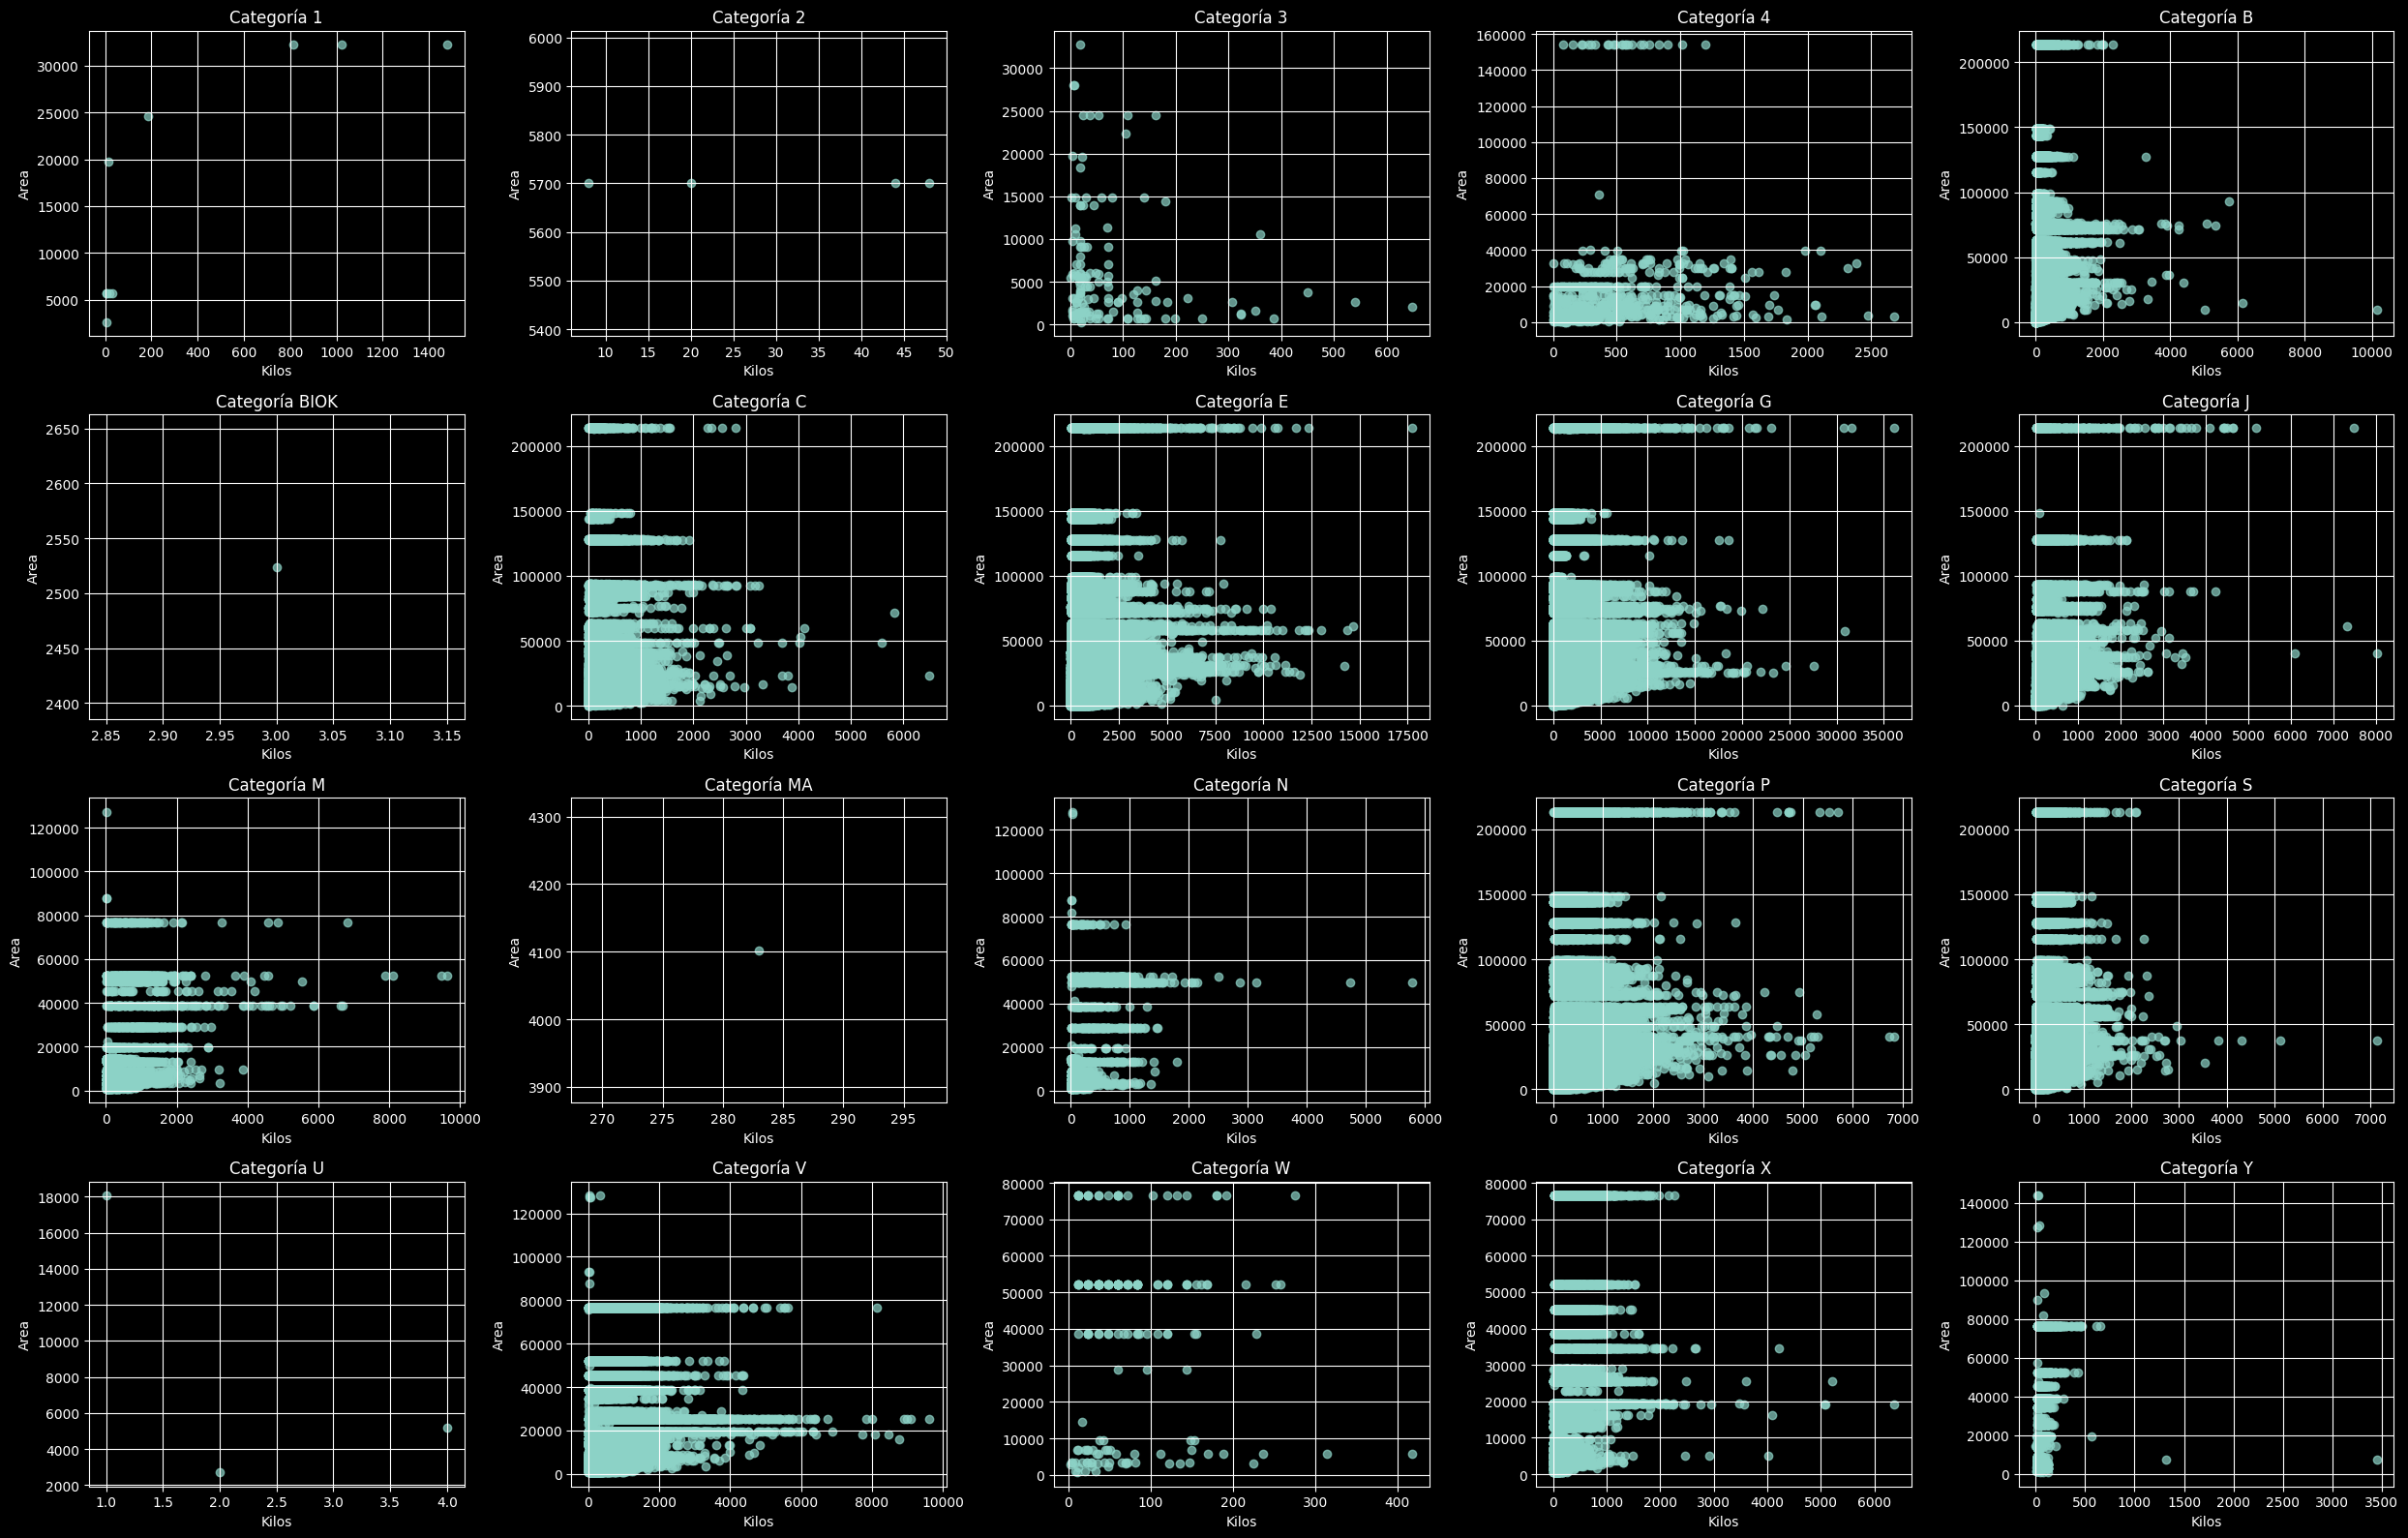

In [3]:
import matplotlib.pyplot as plt
import math

df["Kilos"] = pd.to_numeric(df["Kilos"], errors="coerce")
df["Area"] = pd.to_numeric(df["Area"], errors="coerce")
df = df.dropna(subset=["Kilos", "Area", "Cat"])

categories = sorted(df["Cat"].dropna().unique())
n = len(categories)

cols = 5
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, category in enumerate(categories):
    subset = df[df["Cat"] == category]
    ax = axes[i]
    ax.scatter(subset["Kilos"], subset["Area"], alpha=0.7)
    ax.set_title(f"Categoría {category}")
    ax.set_xlabel("Kilos")
    ax.set_ylabel("Area")
    ax.grid(True)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [4]:
def calculate_count_per_farm():
	result = dict(df["finca"].value_counts())
	return {k: int(result[k]) for k in result}

count_per_farm = calculate_count_per_farm()
selected_farms = list(filter(lambda category: count_per_farm[category] >= 5_000, count_per_farm))
count_per_selected_farm = {c: count_per_farm[c] for c in selected_farms}
len(selected_farms)

27

In [5]:
selected_farms

['2TK00',
 '2RM00',
 '4J501',
 '2ZQ00',
 '3BF01',
 '21K00',
 '21L00',
 '2RL00',
 '4FC01',
 '4IX01',
 '2UG00',
 '2T700',
 '3BD01',
 '21M00',
 '4HI01',
 '4BO00',
 '2FT00',
 '3BC01',
 '2YX00',
 '2FX00',
 '23W00',
 '2YW00',
 '2I800',
 '2FW00',
 '2ZI00',
 '2ZU00',
 '4I801']

In [6]:
df = df[df["Kilos"] >= 1]


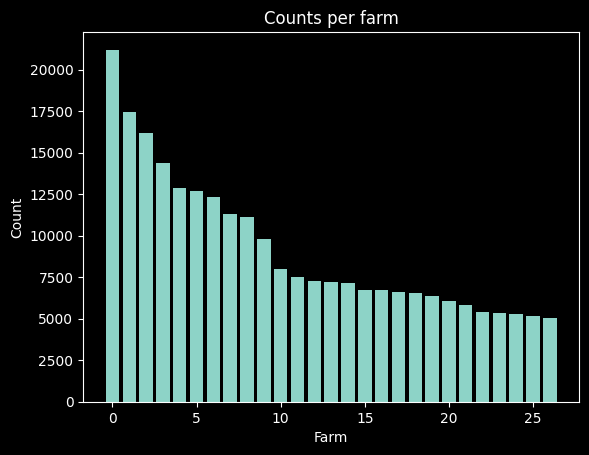

In [7]:
plt.bar(range(len(count_per_selected_farm.keys())), count_per_selected_farm.values())
plt.xlabel("Farm")
plt.ylabel("Count")
plt.title("Counts per farm")
plt.show()
